### Autoreload

Autoreload allows the notebook to dynamically load code: if we update some helper functions *outside* of the notebook, we do not need to reload the notebook.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# All auxiliary code is in ../src

import sys

sys.path.append("../src/")

As first thing we imported all the necessary modules.

In [3]:
import pandas as pd
import seaborn as sbn
import matplotlib.pyplot as plt
from scipy.stats import entropy

Dataset loading

In [4]:
races = pd.read_csv('../dataset/races.csv', sep=",")
imputed_cyclists = pd.read_csv('../dataset/preprocessedCyclists.csv', sep=",")
cyclists = pd.read_csv('../dataset/cyclists.csv', sep=",")
races_pre_imputation=races.copy()

## New feature (lenght/climb total)

In [5]:
races.columns

Index(['_url', 'name', 'points', 'uci_points', 'length', 'climb_total',
       'profile', 'startlist_quality', 'average_temperature', 'date',
       'position', 'cyclist', 'cyclist_age', 'is_tarmac', 'is_cobbled',
       'is_gravel', 'cyclist_team', 'delta'],
      dtype='object')

In [6]:
races['climb/length'] = races['climb_total'] / races['length']

In [7]:
from distribution_utility import stats_and_distribution, show_stats, calculate_outlier_bounds

In [8]:
#extraction of features related to the race and not to the placement
cyclist_races_columns = ['position', 'cyclist', 'cyclist_age', 'cyclist_team', 'delta', 'date'] #date should be discarded since it's the arrival time
races_columns = [col for col in races.columns if col not in cyclist_races_columns]

#races_data will contain all the 'events' in the dataset with their specific information
races_data = races.drop_duplicates(subset=races_columns)[races_columns].reset_index(drop=True)
races_data_pre_imputation=races_data.copy()
races_data

,_url,name,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,is_tarmac,is_cobbled,is_gravel,climb/length
0,tour-de-france/1978/stage-6,Tour de France,100.0,NaN,162000.0,1101.0,1.0,1241,NaN,True,False,False,0.006796
1,vuelta-a-espana/2016/stage-14,Vuelta a España,80.0,100.0,196000.0,5575.0,5.0,821,NaN,True,False,False,0.028444
2,tour-de-france/2019/stage-21,Tour de France,100.0,120.0,128000.0,781.0,1.0,1699,NaN,True,False,False,0.006102
3,volta-a-catalunya/1999/prologue,Volta Ciclista a Catalunya,50.0,NaN,8100.0,NaN,NaN,804,NaN,True,False,False,NaN
4,tour-de-france/2022/stage-9,Tour de France,100.0,120.0,192900.0,3743.0,3.0,1551,24.0,True,False,False,0.019404
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5276,giro-d-italia/2017/stage-3,Giro d'Italia,80.0,100.0,148000.0,1441.0,1.0,881,NaN,True,False,False,0.009736
5277,paris-roubaix/2000/result,Paris - Roubaix,275.0,NaN,273000.0,NaN,1.0,808,NaN,False,False,False,NaN
5278,paris-nice/1976/stage-2,Paris - Nice,50.0,NaN,185000.0,NaN,NaN,779,NaN,True,False,False,NaN
5279,volta-a-catalunya/2016/stage-7,Volta Ciclista a Catalunya,50.0,50.0,136400.0,1880.0,2.0,1045,NaN,True,False,False,0.013783


In [9]:
races_data['climb/length'] = races_data['climb_total'] / races_data['length']

Description of attribute 'climb/length':


count    3067.000000
mean        0.014813
std         0.009059
min         0.000069
25%         0.008803
50%         0.013438
75%         0.018845
max         0.103261
Name: climb/length, dtype: float64


Unique values:
[0.0067963  0.02844388 0.00610156 ... 0.00973649 0.01378299 0.00714286]

Null values: 2214 over 5281 records - (41.92%)

Top 5 common value:
climb/length
0.012440    3
0.029570    3
0.007500    3
0.012376    3
0.015437    2
Name: count, dtype: int64


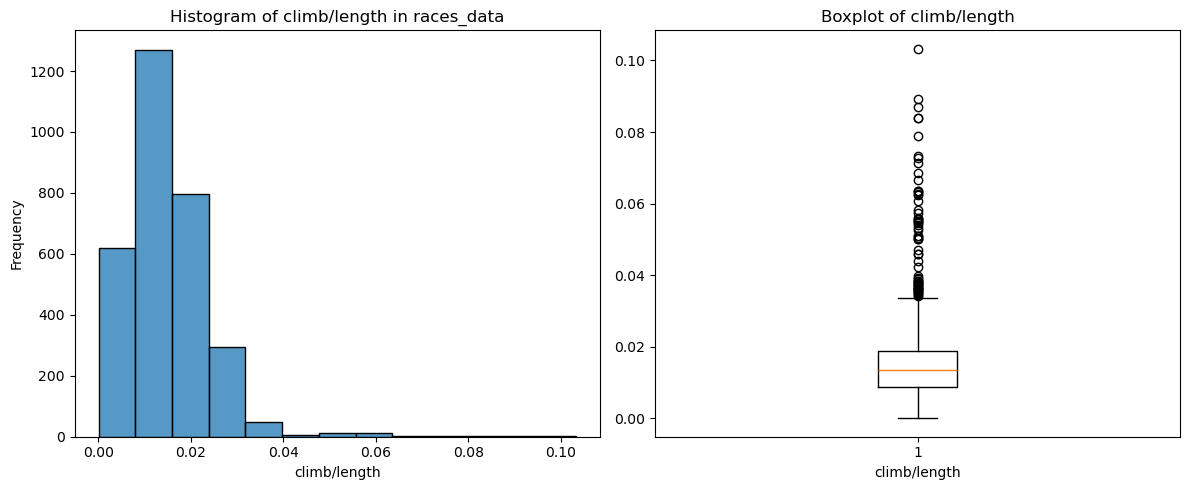

Outliers in climb/length: [0.0625, 0.05580808080808081, 0.03835294117647059, 0.06345833333333334, 0.07268518518518519, 0.05023648648648649, 0.03691275167785235, 0.05395833333333333, 0.05271844660194175, 0.05446575342465754, 0.035765217391304345, 0.0352415210688592, 0.056, 0.03459119496855346, 0.05322916666666667, 0.036375, 0.03806363636363636, 0.03423423423423423, 0.035515151515151513, 0.034926470588235295, 0.03725641025641026, 0.03976470588235294, 0.03772350230414746, 0.044, 0.05821875, 0.05023157894736842, 0.06075313807531381, 0.046052631578947366, 0.05101639344262295, 0.04709090909090909, 0.03624503311258278, 0.04594285714285714, 0.05489583333333333, 0.037445378151260506, 0.07126666666666667, 0.06674074074074074, 0.03928260869565217, 0.05514619883040936, 0.057526881720430106, 0.03906040268456376, 0.087, 0.042339181286549704, 0.034957627118644065, 0.036417910447761194, 0.05092783505154639, 0.036565371024734984, 0.03723684210526316, 0.036036036036036036, 0.06264925373134328, 0.0686875

In [10]:
stats_and_distribution(races_data, 'climb/length', attr_type='numerical')

We can observe that the distribution presents a positive skew with a long tail. This means that most of the races have small a climb/length ratio, in particular the climb part of a race event is typically <4%. The boxplot classifies as outliers all the races with a ratio grater than 2.85%. Notice that there is a single race event with an uphill portion of that constitutes 10% of the total distance.

In [11]:
iqr=(races_data['climb/length'].quantile(0.75))-(races_data['climb/length'].quantile(0.25))
print(f"Upper wisker limit: {races_data['climb/length'].quantile(0.5)+1.5*iqr}")

Upper wisker limit: 0.028501854042755605


In [12]:
races_data[races_data['climb/length']==0.10326086956521739]

,_url,name,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,is_tarmac,is_cobbled,is_gravel,climb/length
1144,tour-de-france/1996/stage-9,Tour de France,100.0,NaN,46000.0,4750.0,5.0,1872,NaN,True,False,False,0.103261


In [13]:
print(f"Correlation between climb/length and profile: {races_data['climb/length'].corr(races_data['profile'], method='kendall')}")
print(f"Correlation between climb and profile: {races_data['climb_total'].corr(races_data['profile'], method='kendall')}")
print(f"Correlation between length and profile: {races_data['length'].corr(races_data['profile'], method='kendall')}")

Correlation between climb/length and profile: 0.6251513605040532
Correlation between climb and profile: 0.572520132871134
Correlation between length and profile: 0.006155688405006674


As shown by the Kendall scores, which is the best metric for assessing correlation with a rank attribute, using the ratio climb/length has increased the correlation with the ordinal feature 'profile' compared to just looking at the 'climb_total' value.

In [14]:
def correlations(dataset: pd.DataFrame) -> pd.DataFrame:
    correlations_dictionary = {
        correlation_type: dataset.corr(numeric_only=True, method=correlation_type)
        for correlation_type in ("kendall", "pearson", "spearman")
    }
    for i, k in enumerate(correlations_dictionary.keys()):
        correlations_dictionary[k].loc[:, "correlation_type"] = k
    correlations_matrix = pd.concat(correlations_dictionary.values())

    return correlations_matrix

In [15]:
correlation_matrix_races_data=correlations(races_data)
correlation_matrix_races_data

,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,is_tarmac,is_cobbled,is_gravel,climb/length,correlation_type
points,1.000000,0.514667,0.327285,0.062379,-0.103855,0.346395,0.118070,-0.514144,NaN,NaN,-0.047898,kendall
uci_points,0.514667,1.000000,0.130646,0.058834,-0.010730,-0.008093,0.040138,-0.378570,NaN,NaN,-0.007390,kendall
length,0.327285,0.130646,1.000000,0.296914,0.006156,0.047565,-0.095148,-0.388565,NaN,NaN,-0.077612,kendall
climb_total,0.062379,0.058834,0.296914,1.000000,0.572520,0.009008,-0.080778,-0.111602,NaN,NaN,0.626271,kendall
profile,-0.103855,-0.010730,0.006156,0.572520,1.000000,-0.076665,-0.013459,0.052719,NaN,NaN,0.625151,kendall
startlist_quality,0.346395,-0.008093,0.047565,0.009008,-0.076665,1.000000,0.205643,0.114783,NaN,NaN,-0.015020,kendall
average_temperature,0.118070,0.040138,-0.095148,-0.080778,-0.013459,0.205643,1.000000,0.235771,NaN,NaN,-0.048647,kendall
is_tarmac,-0.514144,-0.378570,-0.388565,-0.111602,0.052719,0.114783,0.235771,1.000000,NaN,NaN,0.034305,kendall
is_cobbled,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,kendall
is_gravel,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,kendall


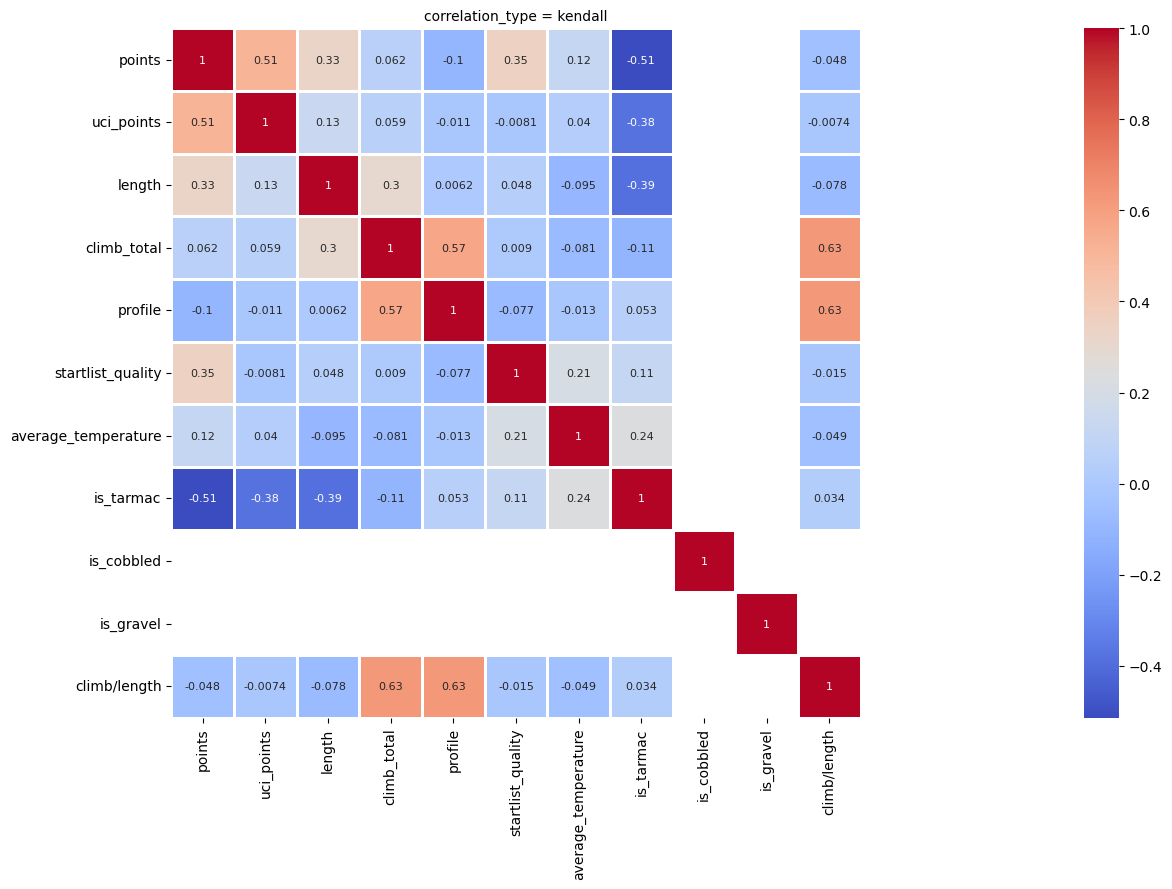

In [16]:
only_pearson=correlation_matrix_races_data[correlation_matrix_races_data['correlation_type'] == 'kendall']
g = sbn.FacetGrid(only_pearson, col="correlation_type", col_wrap=1, height=9, aspect=5)
g.map_dataframe(lambda data, color: sbn.heatmap(
    data[data.columns[:-1]], #Ignore the last column of the matrix which contains the correlation type
    cmap="coolwarm", #Colormap 
    annot=True, #Correlation values inside the cell
    square=True, #Square shape for each cell of the matrix
    cbar=True, #Color bar next to the matrix to "visually" interpret the correlation
    linewidths=1,  #Lines between cells
    annot_kws={"size": 8}  #Font size
))
plt.show()
plt.close()

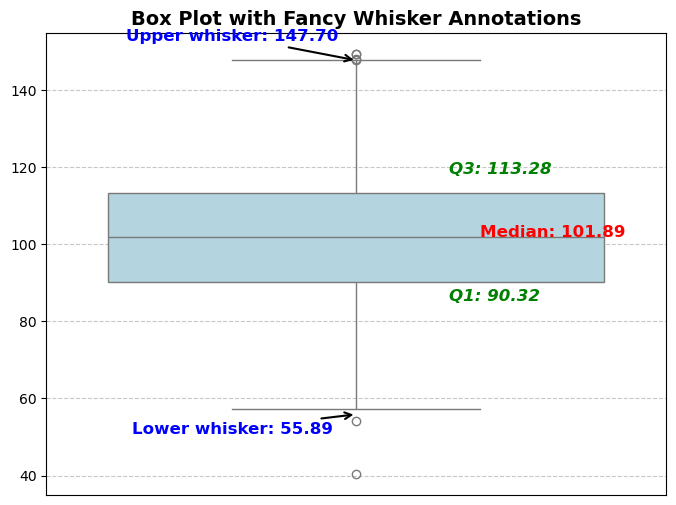

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Generate example data
np.random.seed(10)
data = np.random.normal(100, 20, 200)

# Create a box plot
plt.figure(figsize=(8, 6))
box_plot = sns.boxplot(data=data, color="lightblue")

# Calculate statistics for the box plot (Q1, Q3, whiskers)
q1 = np.percentile(data, 25)
q3 = np.percentile(data, 75)
iqr = q3 - q1  # Interquartile range
median = np.percentile(data, 50)

# Calculate whiskers
lower_whisker = max(min(data), q1 - 1.5 * iqr)
upper_whisker = min(max(data), q3 + 1.5 * iqr)

# Annotate whiskers with arrows and styled text
plt.annotate(f'Lower whisker: {lower_whisker:.2f}',
             xy=(0, lower_whisker), xytext=(-0.2, lower_whisker - 5),
             arrowprops=dict(facecolor='blue', arrowstyle="->", lw=1.5),
             ha='center', color='blue', fontsize=12, fontweight='bold')

plt.annotate(f'Upper whisker: {upper_whisker:.2f}',
             xy=(0, upper_whisker), xytext=(-0.2, upper_whisker + 5),
             arrowprops=dict(facecolor='blue', arrowstyle="->", lw=1.5),
             ha='center', color='blue', fontsize=12, fontweight='bold')

# Annotate Q1, Q3, and Median with styled text
plt.annotate(f'Q1: {q1:.2f}', xy=(0, q1), xytext=(0.15, q1 - 5),
             color='green', fontsize=12, fontstyle='italic', fontweight='bold')
plt.annotate(f'Q3: {q3:.2f}', xy=(0, q3), xytext=(0.15, q3 + 5),
             color='green', fontsize=12, fontstyle='italic', fontweight='bold')
plt.annotate(f'Median: {median:.2f}', xy=(0, median), xytext=(0.2, median),
             color='red', fontsize=12, fontweight='bold')

# Customize plot aesthetics
plt.title("Box Plot with Fancy Whisker Annotations", fontsize=14, fontweight='bold')
plt.xticks([])
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show plot
plt.show()


In [18]:
nrec = races.shape[0]
results = {
    'Feature': [],
    'Null_counter': [],
    'Perc_of_null_(%)': []
}

for col in races.columns:
    nanCount = races[col].isna().sum()
    perc = round((nanCount*100)/nrec,1)
    results['Feature'].append(col)
    results['Null_counter'].append(nanCount)
    results['Perc_of_null_(%)'].append(perc)

df_results = pd.DataFrame(results)

display(df_results)

,Feature,Null_counter,Perc_of_null_(%)
0,_url,0,0.0
1,name,0,0.0
2,points,477,0.1
3,uci_points,338779,57.4
4,length,0,0.0
5,climb_total,147045,24.9
6,profile,148194,25.1
7,startlist_quality,0,0.0
8,average_temperature,559932,94.9
9,date,0,0.0


## Points imputation

In [19]:
races_data[races_data['points'].isna()]

,_url,name,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,is_tarmac,is_cobbled,is_gravel,climb/length
1423,vuelta-a-espana/1994/stage-5,Vuelta a España,NaN,NaN,166900.0,1547.0,NaN,791,NaN,True,False,False,0.009269
4167,tour-de-france/1986/stage-19,Tour de France,NaN,NaN,179500.0,3000.0,4.0,1872,NaN,True,False,False,0.016713
4661,tour-de-france/1988/prologue,Tour de France,NaN,NaN,1000.0,44.0,1.0,1941,NaN,True,False,False,0.044000
5035,tour-de-france/2019/stage-19,Tour de France,NaN,NaN,89000.0,2995.0,5.0,1699,NaN,True,False,False,0.033652


As we can see there are only 4 race events for which we have not the point reference. Let's see again which 'points' are typically assigned to a race; we expect them to be to assume values in a defined set/range.

In [20]:
points_set=np.sort(races_data['points'].unique())
points_set

array([ 18.,  20.,  30.,  35.,  50.,  70.,  75.,  80., 100., 125., 150.,
       225., 275., 350.,  nan])

In [21]:
tdf_no_points=races_data[races_data['_url'].str.contains(r'tour-de-france/\d{4}/stage-19', regex=True)].sort_values(by="_url")
tdf_no_points

,_url,name,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,is_tarmac,is_cobbled,is_gravel,climb/length
230,tour-de-france/1978/stage-19,Tour de France,100.0,NaN,182000.0,2000.0,2.0,1241,NaN,True,False,False,0.010989
334,tour-de-france/1979/stage-19,Tour de France,100.0,NaN,162000.0,1568.0,2.0,1381,NaN,True,False,False,0.009679
1927,tour-de-france/1980/stage-19,Tour de France,100.0,NaN,136500.0,2439.0,4.0,1224,NaN,True,False,False,0.017868
971,tour-de-france/1981/stage-19,Tour de France,100.0,NaN,117500.0,1996.0,2.0,1362,NaN,True,False,False,0.016987
5055,tour-de-france/1982/stage-19,Tour de France,100.0,NaN,48000.0,508.0,2.0,1492,NaN,True,False,False,0.010583
1310,tour-de-france/1983/stage-19,Tour de France,100.0,NaN,15000.0,1069.0,5.0,1269,NaN,True,False,False,0.071267
913,tour-de-france/1984/stage-19,Tour de France,100.0,NaN,186000.0,5500.0,4.0,1632,NaN,True,False,False,0.029570
3530,tour-de-france/1985/stage-19,Tour de France,100.0,NaN,200000.0,1637.0,1.0,1470,NaN,True,False,False,0.008185
4167,tour-de-france/1986/stage-19,Tour de France,NaN,NaN,179500.0,3000.0,4.0,1872,NaN,True,False,False,0.016713
1770,tour-de-france/1987/stage-19,Tour de France,100.0,NaN,185000.0,4842.0,4.0,1812,NaN,True,False,False,0.026173


In [22]:
tour_de_france_df = races_data[races_data['_url'].str.startswith('tour-de-france')]
tour_de_france_df['points'].value_counts(normalize=True)

points
100.0    0.975771
70.0     0.023128
50.0     0.001101
Name: proportion, dtype: float64

We can observe that 97% of the stages of the "Tour de France" have a score of 100. Since the scores are "drawn" from a specific set, as already told before, it's reasonable to assign the score 100 to the 3 stages of the "Tour de France" with a NaN reference.

In [23]:
rows_to_fill = races_data[(races_data['_url'].str.startswith('tour-de-france'))&(races_data['points'].isna())]
rows_to_fill

,_url,name,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,is_tarmac,is_cobbled,is_gravel,climb/length
4167,tour-de-france/1986/stage-19,Tour de France,NaN,NaN,179500.0,3000.0,4.0,1872,NaN,True,False,False,0.016713
4661,tour-de-france/1988/prologue,Tour de France,NaN,NaN,1000.0,44.0,1.0,1941,NaN,True,False,False,0.044000
5035,tour-de-france/2019/stage-19,Tour de France,NaN,NaN,89000.0,2995.0,5.0,1699,NaN,True,False,False,0.033652


In [24]:
rows_to_fill.loc[:, 'points'] = rows_to_fill['points'].fillna(100)
races_data.update(rows_to_fill) #update the dataframe which still have NaNs

In [25]:
races_data[races_data['points'].isna()]


,_url,name,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,is_tarmac,is_cobbled,is_gravel,climb/length
1423,vuelta-a-espana/1994/stage-5,Vuelta a España,NaN,NaN,166900.0,1547.0,NaN,791,NaN,True,False,False,0.009269


In [26]:
vae_no_points=races_data[races_data['_url'].str.startswith('vuelta-a-espana')]
vae_no_points['points'].value_counts(normalize=True)

points
80.0    0.996641
50.0    0.003359
Name: proportion, dtype: float64

Since 99% of the race events related to '_vuelta-a-espana_' have a score of 80, we decide to impute the only stage with a NaN using this value.

In [27]:
rows_to_fill = races_data[(races_data['_url'].str.startswith('vuelta-a-espana'))&(races_data['points'].isna())]
rows_to_fill.loc[:, 'points'] = rows_to_fill['points'].fillna(80)
races_data.update(rows_to_fill) #update the dataframe which still have NaNs

In [28]:
races_data[races_data['points'].isna()]

,_url,name,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,is_tarmac,is_cobbled,is_gravel,climb/length


In [29]:
def imputationComparison(original_df, imputed_df, column):
    #Two plots in the same row
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    sbn.histplot(original_df, x=column, ax=axes[0], kde=True)
    axes[0].set_title(f'Histogram of "{column}" pre-imputation')
    axes[0].set_xlabel(column)
    axes[0].set_ylabel('Frequency')

    sbn.histplot(imputed_df, x=column, ax=axes[1], kde=True)
    axes[1].set_title(f'Histogram of "{column}" after-imputation')
    axes[1].set_xlabel(column)
    axes[1].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()
    plt.close()

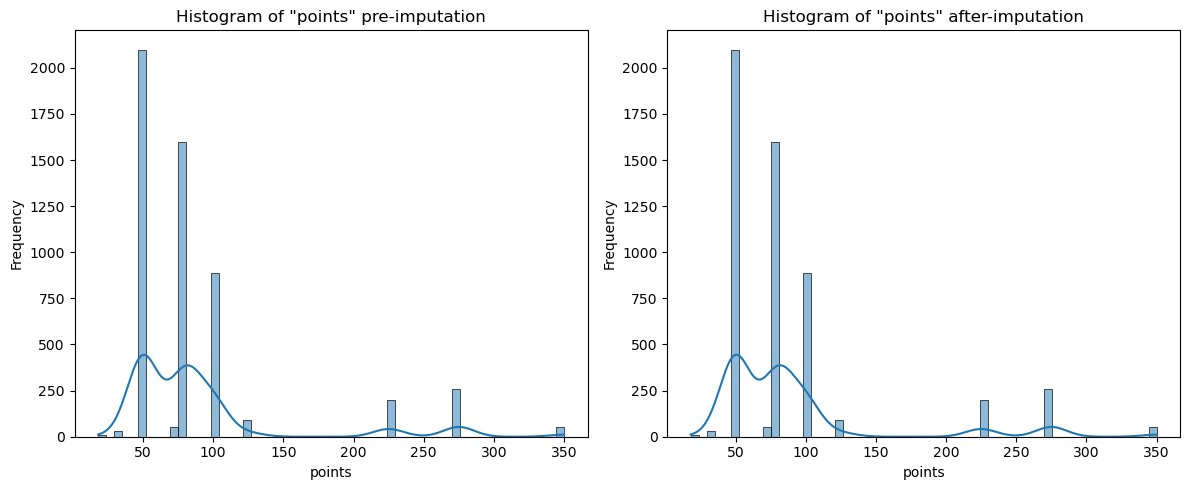

In [30]:
imputationComparison(races_data_pre_imputation, races_data, 'points')

Since we have operated on few races. 

## Cyclist age (& Birth year)

In [31]:
cyclists.columns

Index(['_url', 'name', 'birth_year', 'weight', 'height', 'nationality'], dtype='object')

In [32]:
imputed_cyclists.columns

Index(['name', 'BMI', 'median position', 'AVG position', '# cyclist races',
       'nationality', 'continent', 'geo area', 'birth_year',
       'AVG weighted position', 'AVG position Autumn', 'AVG position Spring',
       'AVG position Summer', 'AVG position Winter', 'AVG position Q1',
       'AVG position Q2', 'AVG position Q3', 'AVG position Q4',
       'std_dev position'],
      dtype='object')

In [33]:
#Cyclists without a 'cyclist_age' reference in 'races'
no_age_in_races=races[races['cyclist_age'].isna()]['cyclist'].drop_duplicates().tolist()
sorted(no_age_in_races)


['alexandr-osipov',
 'antonio-zanini',
 'batik-odriozola',
 'carlos-garcia',
 'filippo-simonetti',
 'javier-luquin',
 'nevens-guy',
 'nicolai-kosyakov',
 'oscar-pumar',
 'scott-davies',
 'sergei-jermachenko',
 'thierry-lauder',
 'vladimir-malakov']

In [34]:
#Cyclists without a 'birth_year' reference in 'cyclist' after the initial imputation
no_by_in_cyclists=imputed_cyclists[imputed_cyclists['birth_year'].isna()]['name'].drop_duplicates().tolist()
sorted(no_by_in_cyclists)

['alexandr-osipov',
 'batik-odriozola',
 'carlos-garcia',
 'filippo-simonetti',
 'javier-luquin',
 'nevens-guy',
 'nicolai-kosyakov',
 'oscar-pumar',
 'sergei-jermachenko',
 'thierry-lauder']

We can see that after the '_birth year_' imputation on the 'cyclists' dataset, we can determine the correct value for 3 cyclists with a NaN '_cyclist age_'; these cyclists are 'antonio-zanini', 'scott-davies', 'vladimir-malakov'.

The other cyclists with a NaN '_cyclist age_' in the 'races' dataset also have a NaN '_birth year_' in the 'cyclists' dataset. So we can decide to impute one of the two features and automatically determine the values for the other.

Since the '_cyclist age_'Info related to the cyclist placement hence update the dataframe 'races.

In [35]:
races['date'] = pd.to_datetime(races['date']).dt.floor('d')

### Birth year known

In [36]:
print(races[races['cyclist'] == 'antonio-zanini']['date'].dt.year.value_counts())
#All the races the same year
rows_to_fill = races[races['cyclist']== 'antonio-zanini']


date
1990    2
Name: count, dtype: int64


In [37]:
cyclist_age=rows_to_fill['date'].iloc[0].year-imputed_cyclists[imputed_cyclists['name']=='antonio-zanini']['birth_year'].iloc[0]
#All the races in the same year
print(f'In all the races in which he has participated, antonio zanini was {cyclist_age}')
rows_to_fill.loc[:, 'cyclist_age'] = rows_to_fill['cyclist_age'].fillna(cyclist_age)
races.update(rows_to_fill) 

In all the races in which he has participated, antonio zanini was 25.0


In [38]:
races[races['cyclist']=='antonio-zanini'][['cyclist', 'cyclist_age', 'date']] #post imputation

,cyclist,cyclist_age,date
21373,antonio-zanini,25.0,1990-04-01
555652,antonio-zanini,25.0,1990-04-08


In [39]:
print(races[races['cyclist'] == 'vladimir-malakov']['date'].dt.year.value_counts())
#All the races the same year
rows_to_fill = races[races['cyclist']== 'vladimir-malakov']

date
1985    14
Name: count, dtype: int64


In [40]:
cyclist_age=rows_to_fill['date'].iloc[0].year-imputed_cyclists[imputed_cyclists['name']=='vladimir-malakov']['birth_year'].iloc[0]
#All the races in the same year
print(f'In all the races in which he has participated, vladimir-malakov was {cyclist_age}')
rows_to_fill.loc[:, 'cyclist_age'] = rows_to_fill['cyclist_age'].fillna(cyclist_age)
races.update(rows_to_fill) 

In all the races in which he has participated, vladimir-malakov was 27.0


In [41]:
races[races['cyclist']=='vladimir-malakov'][['cyclist', 'cyclist_age', 'date']]

,cyclist,cyclist_age,date
30249,vladimir-malakov,27.0,1985-05-05
37684,vladimir-malakov,27.0,1985-05-12
79444,vladimir-malakov,27.0,1985-05-11
112356,vladimir-malakov,27.0,1985-04-28
176522,vladimir-malakov,27.0,1985-05-10
179083,vladimir-malakov,27.0,1985-04-23
227520,vladimir-malakov,27.0,1985-05-09
283428,vladimir-malakov,27.0,1985-05-01
329685,vladimir-malakov,27.0,1985-04-26
340161,vladimir-malakov,27.0,1985-04-30


In [42]:
print(races[races['cyclist'] == 'scott-davies']['date'].dt.year.value_counts())
#Races in different years!

date
2019    29
2020    18
2018     5
Name: count, dtype: int64


In [43]:
#Races in 2018
year=2018
for year in range(2018, 2021):
    # Select the rows related to races of scott davies in 'year'
    rows_to_fill = races[(races['cyclist']== 'scott-davies')&(races['date'].dt.year==year)]
    cyclist_age=rows_to_fill['date'].iloc[0].year-imputed_cyclists[imputed_cyclists['name']=='scott-davies']['birth_year'].iloc[0]
    print(f'In all the races of {year} in which he has participated, scott-davies was {cyclist_age}')
    rows_to_fill.loc[:, 'cyclist_age'] = rows_to_fill['cyclist_age'].fillna(cyclist_age)
    races.update(rows_to_fill) 

In all the races of 2018 in which he has participated, scott-davies was 23.0
In all the races of 2019 in which he has participated, scott-davies was 24.0
In all the races of 2020 in which he has participated, scott-davies was 25.0


In [44]:
races[races['cyclist']=='scott-davies'][['cyclist', 'cyclist_age', 'date']]

,cyclist,cyclist_age,date
2063,scott-davies,24.0,2019-05-25
6495,scott-davies,25.0,2020-10-27
12865,scott-davies,23.0,2018-04-15
12972,scott-davies,25.0,2020-10-31
13349,scott-davies,24.0,2019-03-12
23038,scott-davies,24.0,2019-05-28
60389,scott-davies,25.0,2020-10-23
68791,scott-davies,24.0,2019-05-19
75497,scott-davies,24.0,2019-05-30
132853,scott-davies,24.0,2019-03-10


### Birth year unknown

In [45]:
imputed_cyclists[imputed_cyclists['name'].isin(no_by_in_cyclists)][['name', '# cyclist races']].sort_values('# cyclist races', ascending=False)

,name,# cyclist races
4091,sergei-jermachenko,14
4086,alexandr-osipov,13
4098,nicolai-kosyakov,11
4027,filippo-simonetti,1
4815,nevens-guy,1
5292,thierry-lauder,1
5672,carlos-garcia,1
5679,javier-luquin,1
5831,oscar-pumar,1
6059,batik-odriozola,1


Many of these cyclists have participated only in one race event. The idea is to replace the missing age of the cyclists with the median age, taking into account the races in which they have participated. 

In [46]:
races['year'] = races['date'].dt.year
races[races['cyclist'].isin(no_by_in_cyclists)][['cyclist', 'year']].value_counts()

cyclist             year
sergei-jermachenko  1985    14
alexandr-osipov     1985    12
nicolai-kosyakov    1985    11
alexandr-osipov     1986     1
batik-odriozola     1997     1
carlos-garcia       2001     1
filippo-simonetti   1997     1
javier-luquin       1992     1
nevens-guy          1993     1
oscar-pumar         1995     1
thierry-lauder      2000     1
Name: count, dtype: int64

Only Alexandr Osipov has taken part in the race in different years.

In [47]:
print(races[races['cyclist'] == 'alexandr-osipov']['date'].dt.year.value_counts())

date
1985    12
1986     1
Name: count, dtype: int64


In [48]:
#Iterate over all the cyclists without birth year
for cyclist in no_by_in_cyclists:
    #Extract the races in which he has participated (the _url)
    races_in_which_he_has_participated=races[races['cyclist']==cyclist]['_url']

    #Determine the median age of the participants of the races in which the cyclist took part in
    median_age=races[races['_url'].isin(races_in_which_he_has_participated)]['cyclist_age'].median()
    print(f"The median age of the race events in which {cyclist} took part was {median_age}")
    
    #With the exception of 'Alexandr-Osipov', all the cyclists have only taken part in races in the same year.
    if cyclist!= 'alexandr-osipov':
        #Extract the rows to fill
        rows_to_fill = races[(races['cyclist']== cyclist)]
        #Fill NaNs
        rows_to_fill.loc[:, 'cyclist_age'] = rows_to_fill['cyclist_age'].fillna(median_age)
        races.update(rows_to_fill) 
    else:
        #He participated in 12 race events in 1985 and only 1 in 1986
        rows_to_fill = races[(races['cyclist']== cyclist)&(races['date'].dt.year==1985)]
        rows_to_fill.loc[:, 'cyclist_age'] = rows_to_fill['cyclist_age'].fillna(median_age)
        races.update(rows_to_fill) 
        rows_to_fill = races[(races['cyclist']== cyclist)&(races['date'].dt.year==1986)]
        rows_to_fill.loc[:, 'cyclist_age'] = rows_to_fill['cyclist_age'].fillna(median_age+1)
        races.update(rows_to_fill) 

The median age of the race events in which filippo-simonetti took part was 28.0


C:\Users\simon\AppData\Local\Temp\ipykernel_19756\1219897084.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[1978 1978 1978 ... 2010 2010 2010]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  races.update(rows_to_fill)


The median age of the race events in which alexandr-osipov took part was 26.0
The median age of the race events in which sergei-jermachenko took part was 26.0
The median age of the race events in which nicolai-kosyakov took part was 26.0
The median age of the race events in which nevens-guy took part was 28.0
The median age of the race events in which thierry-lauder took part was 28.0
The median age of the race events in which carlos-garcia took part was 28.0
The median age of the race events in which javier-luquin took part was 27.0
The median age of the race events in which oscar-pumar took part was 28.0
The median age of the race events in which batik-odriozola took part was 27.0


In [49]:
print(f"After the imputation there are {races[races['cyclist_age'].isna()].shape[0]} rows with still a NaN value.")

After the imputation there are 0 rows with still a NaN value.


In [ ]:
imputationComparison(races_pre_imputation, races, 'cyclist_age')

In [ ]:
plt.figure(figsize=(8, 6))

#Unique boxplot with multiple datasets representing the initial situation and the imputation strategies
plt.boxplot(
    [races_pre_imputation['cyclist_age'].dropna(), races['cyclist_age']],
    labels=['Pre-Imputation', 'After Imputation']
)
plt.title("Boxplot of cyclist_age before and after the imputation phase")
plt.ylabel("Age")
plt.show()
plt.close()

In [ ]:
races.boxplot(column='cyclist_age')

## Climb total


In [ ]:
import pandas as pd
races_data = pd.read_csv('../dataset/preprocessedRacesData.csv', sep=",")
races_data_pre_imputation=races_data.copy()
races = pd.read_csv('../dataset/preprocessedRaces.csv', sep=",")

In [ ]:
races_data.isna().sum()

In [ ]:
races_data.isna().shape[0]

There are 2214 missing '_climb total_' over 5281 race events, almost the 42%.

In [ ]:
races_data[races_data['climb_total'].isna()]

In [ ]:
races_data.dtypes

In [ ]:
from sklearn.impute import KNNImputer
#Missing value mitigation using the value of the "near" (in the KNN sense) instances

columns_for_imputation = ['climb_total', 'length', 'profile', 'startlist_quality']
imputer = KNNImputer(n_neighbors=4,weights="distance")
imputed_data = imputer.fit_transform(races_data[columns_for_imputation])

In [ ]:
df_imputed=pd.DataFrame(imputed_data, columns=columns_for_imputation)
races_data['climb_total']=df_imputed['climb_total']

In [ ]:
races_data['climb_total'].isna().any()

In [ ]:
imputationComparison(races_data_pre_imputation, races_data, 'climb_total')

In [ ]:
races_data.isna().sum()

In [ ]:
plt.figure(figsize=(8, 6))

#Unique boxplot with multiple datasets representing the initial situation and the imputation strategies
plt.boxplot(
    [races_data_pre_imputation['climb_total'].dropna(), races_data['climb_total']],
    labels=['Pre-Imputation', 'After Imputation']
)
plt.title("Boxplot of climb_total before and after the imputation phase")
plt.ylabel("climb_total")
plt.show()
plt.close()

- provare ad inserire il rapporto tra le features da tenere in considerazione
- provare diversi valori di k